Learning the ropes of FAST F1

In [34]:
import fastf1
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display


In [3]:
fastf1.Cache.enable_cache('../f1_cache')

In [5]:
session = fastf1.get_session(2025,'Austin','S')
session.load()

core           INFO 	Loading data for United States Grand Prix - Sprint [v3.8.1]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INF

Learning Basics

In [13]:

laps = session.laps
raceLaps = laps.dropna(subset=['LapTime']).copy()



raceLaps = raceLaps[raceLaps['PitOutTime'].isnull() & raceLaps['PitInTime'].isnull()].copy()


raceLaps['LapTime_Sec'] = raceLaps['LapTime'].dt.total_seconds()


Laps = raceLaps[raceLaps['LapTime_Sec'] < (raceLaps['LapTime_Sec'].min() * 1.07)]


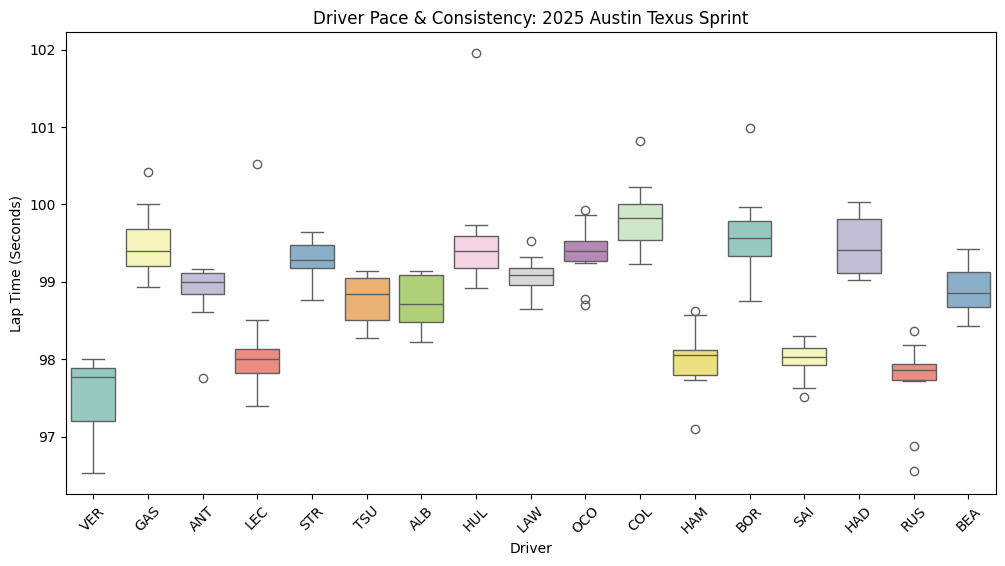

In [15]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=Laps, x='Driver', y='LapTime_Sec', palette='Set3',hue='Driver',legend=False)
plt.title('Driver Pace & Consistency: 2025 Austin Texus Sprint')
plt.xlabel('Driver')
plt.ylabel('Lap Time (Seconds)')
plt.xticks(rotation=45)
plt.show()

1. Find the absolute fastest lap time of the sprint.
2. Find out WHICH driver set that fastest lap.
3. Calculate the average (mean) lap time for all drivers.
4. Print all of the above.

In [37]:
#Task 1
#print(Laps)
LapTimes = Laps['LapTime']
FastestLap = Laps['LapTime'].min()
meanLap = Laps['LapTime'].mean()
print(FastestLap,meanLap)

DriverAvgs = Laps.groupby('Driver')['LapTime'].mean()
DriverFastest = Laps.groupby('Driver')['LapTime'].min()
display(DriverAvgs,DriverFastest)

TeamMeans = Laps.groupby('Team')['LapTime'].mean()
FastestTeams = Laps.groupby('Team')['LapTime'].min()
display(TeamMeans,FastestTeams)


0 days 00:01:36.527000 0 days 00:01:38.845058823


Driver
ALB   0 days 00:01:38.722100
ANT   0 days 00:01:38.864200
BEA   0 days 00:01:38.893900
BOR   0 days 00:01:39.599800
COL   0 days 00:01:39.829300
GAS   0 days 00:01:39.486600
HAD   0 days 00:01:39.455500
HAM   0 days 00:01:38.002400
HUL   0 days 00:01:39.602500
LAW   0 days 00:01:39.067400
LEC   0 days 00:01:38.204100
OCO   0 days 00:01:39.370000
RUS   0 days 00:01:37.705300
SAI   0 days 00:01:37.991500
STR   0 days 00:01:39.299100
TSU   0 days 00:01:38.779200
VER   0 days 00:01:37.493100
Name: LapTime, dtype: timedelta64[ns]

Driver
ALB   0 days 00:01:38.220000
ANT   0 days 00:01:37.758000
BEA   0 days 00:01:38.435000
BOR   0 days 00:01:38.746000
COL   0 days 00:01:39.235000
GAS   0 days 00:01:38.932000
HAD   0 days 00:01:39.018000
HAM   0 days 00:01:37.096000
HUL   0 days 00:01:38.917000
LAW   0 days 00:01:38.654000
LEC   0 days 00:01:37.391000
OCO   0 days 00:01:38.701000
RUS   0 days 00:01:36.556000
SAI   0 days 00:01:37.510000
STR   0 days 00:01:38.766000
TSU   0 days 00:01:38.268000
VER   0 days 00:01:36.527000
Name: LapTime, dtype: timedelta64[ns]

Team
Alpine            0 days 00:01:39.657950
Aston Martin      0 days 00:01:39.299100
Ferrari           0 days 00:01:38.103250
Haas F1 Team      0 days 00:01:39.131950
Kick Sauber       0 days 00:01:39.601150
Mercedes          0 days 00:01:38.284750
Racing Bulls      0 days 00:01:39.261450
Red Bull Racing   0 days 00:01:38.136150
Williams          0 days 00:01:38.356800
Name: LapTime, dtype: timedelta64[ns]

Team
Alpine            0 days 00:01:38.932000
Aston Martin      0 days 00:01:38.766000
Ferrari           0 days 00:01:37.096000
Haas F1 Team      0 days 00:01:38.435000
Kick Sauber       0 days 00:01:38.746000
Mercedes          0 days 00:01:36.556000
Racing Bulls      0 days 00:01:38.654000
Red Bull Racing   0 days 00:01:36.527000
Williams          0 days 00:01:37.510000
Name: LapTime, dtype: timedelta64[ns]

Level 2: More advanced Metrics and better understanding

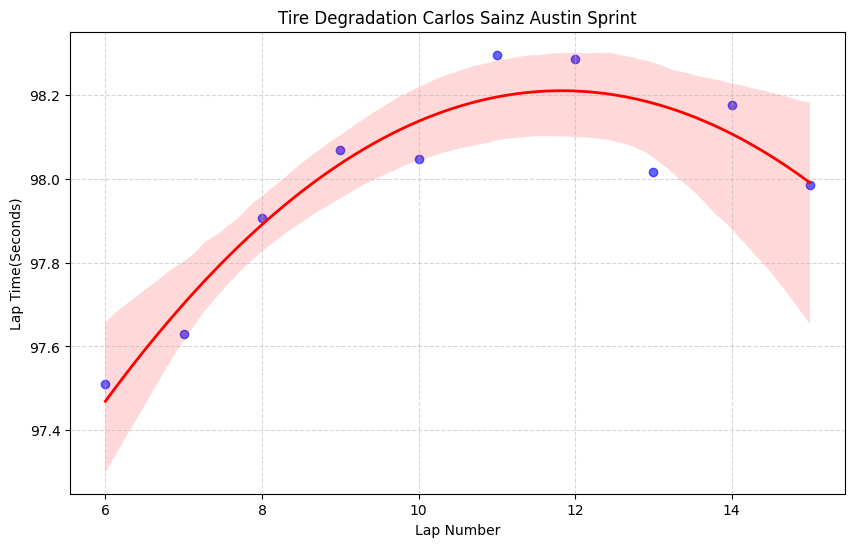

In [40]:
sainz_data = Laps[Laps['Driver'] == 'SAI'].copy()

plt.figure(figsize=(10, 6))
sns.regplot(
    data=sainz_data, 
    x='LapNumber', 
    y='LapTime_Sec', 
    order=2, 
    scatter_kws={'color': 'blue', 'alpha': 0.6}, 
    line_kws={'color': 'red', 'linewidth': 2}
)

plt.title('Tire Degradation Carlos Sainz Austin Sprint')
plt.xlabel('Lap Number')
plt.ylabel('Lap Time(Seconds)')
plt.grid(True,linestyle='--',alpha=0.5)
plt.show()

1. The Teammate Delta (Data Merging)
2. The Metronome (Statistical Variance)
3. Sector Dominance (Advanced Filtering)

In [47]:
charles_data = Laps[Laps['Driver'] == 'LEC'].copy()
#display(sainz_data,charles_data)
rivalCompare = pd.merge(sainz_data,charles_data,on='LapNumber',suffixes=("_SAI","_LEC"))
rivalCompare['TimeDiff'] = rivalCompare['LapTime_Sec_SAI'] - rivalCompare['LapTime_Sec_LEC']
display(rivalCompare)


,Time_SAI,Driver_SAI,DriverNumber_SAI,LapTime_SAI,LapNumber,Stint_SAI,PitOutTime_SAI,PitInTime_SAI,Sector1Time_SAI,Sector2Time_SAI,...,LapStartTime_LEC,LapStartDate_LEC,TrackStatus_LEC,Position_LEC,Deleted_LEC,DeletedReason_LEC,FastF1Generated_LEC,IsAccurate_LEC,LapTime_Sec_LEC,TimeDiff
0,0 days 01:01:26.057000,SAI,55,0 days 00:01:37.510000,6.0,1.0,NaT,NaT,0 days 00:00:26.544000,0 days 00:00:39.240000,...,0 days 00:59:49.206000,2025-10-18 17:16:03.512,1,4.0,False,,False,True,97.869,-0.359
1,0 days 01:03:03.686000,SAI,55,0 days 00:01:37.629000,7.0,1.0,NaT,NaT,0 days 00:00:26.212000,0 days 00:00:39.339000,...,0 days 01:01:27.075000,2025-10-18 17:17:41.381,1,4.0,False,,False,True,97.391,0.238
2,0 days 01:04:41.592000,SAI,55,0 days 00:01:37.906000,8.0,1.0,NaT,NaT,0 days 00:00:26.103000,0 days 00:00:39.571000,...,0 days 01:03:04.466000,2025-10-18 17:19:18.772,1,4.0,False,,False,True,97.812,0.094
3,0 days 01:06:19.660000,SAI,55,0 days 00:01:38.068000,9.0,1.0,NaT,NaT,0 days 00:00:26.243000,0 days 00:00:39.610000,...,0 days 01:04:42.278000,2025-10-18 17:20:56.584,1,5.0,False,,False,True,100.524,-2.456
4,0 days 01:07:57.706000,SAI,55,0 days 00:01:38.046000,10.0,1.0,NaT,NaT,0 days 00:00:26.398000,0 days 00:00:39.505000,...,0 days 01:06:22.802000,2025-10-18 17:22:37.108,1,5.0,False,,False,True,97.731,0.315
5,0 days 01:09:36,SAI,55,0 days 00:01:38.294000,11.0,1.0,NaT,NaT,0 days 00:00:26.362000,0 days 00:00:39.840000,...,0 days 01:08:00.533000,2025-10-18 17:24:14.839,1,5.0,False,,False,True,98.156,0.138
6,0 days 01:11:14.285000,SAI,55,0 days 00:01:38.285000,12.0,1.0,NaT,NaT,0 days 00:00:26.294000,0 days 00:00:39.772000,...,0 days 01:09:38.689000,2025-10-18 17:25:52.995,1,5.0,False,,False,True,98.506,-0.221
7,0 days 01:12:52.301000,SAI,55,0 days 00:01:38.016000,13.0,1.0,NaT,NaT,0 days 00:00:26.239000,0 days 00:00:39.739000,...,0 days 01:11:17.195000,2025-10-18 17:27:31.501,1,5.0,False,,False,True,97.966,0.050
8,0 days 01:14:30.476000,SAI,55,0 days 00:01:38.175000,14.0,1.0,NaT,NaT,0 days 00:00:26.307000,0 days 00:00:39.691000,...,0 days 01:12:55.161000,2025-10-18 17:29:09.467,1,5.0,False,,False,True,98.039,0.136
9,0 days 01:16:08.462000,SAI,55,0 days 00:01:37.986000,15.0,1.0,NaT,NaT,0 days 00:00:26.279000,0 days 00:00:39.582000,...,0 days 01:14:33.200000,2025-10-18 17:30:47.506,1,5.0,False,,False,True,98.047,-0.061


In [66]:
consistentDriver = Laps.groupby('Driver')['LapTime_Sec'].agg(['mean', 'std'])
display(consistentDriver.sort_values(by='std',ascending=True))

,mean,std
Driver,,
LAW,99.0674,0.253480
SAI,97.9915,0.256327
STR,99.2991,0.259283
TSU,98.7792,0.314941
BEA,98.8939,0.317206
ALB,98.7221,0.371035
HAD,99.4555,0.389686
OCO,99.3700,0.396651
ANT,98.8642,0.423770


In [65]:
Laps['Sector1_Sec'] = Laps['Sector1Time'].dt.total_seconds()
Laps['Sector2_Sec'] = Laps['Sector2Time'].dt.total_seconds()
Laps['Sector3_Sec'] = Laps['Sector3Time'].dt.total_seconds()

idx1 = Laps['Sector1_Sec'].idxmin()
idx2 = Laps['Sector2_Sec'].idxmin()
idx3 = Laps['Sector3_Sec'].idxmin()

best_indices = [idx1, idx2, idx3]
results = Laps.loc[best_indices, ['Driver', 'Sector1_Sec', 'Sector2_Sec', 'Sector3_Sec']]
print("--- SECTOR KINGS ---")
display(results)

--- SECTOR KINGS ---


C:\Users\itszaman7\AppData\Local\Temp\ipykernel_11108\32614903.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Laps['Sector1_Sec'] = Laps['Sector1Time'].dt.total_seconds()
C:\Users\itszaman7\AppData\Local\Temp\ipykernel_11108\32614903.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Laps['Sector2_Sec'] = Laps['Sector2Time'].dt.total_seconds()
C:\Users\itszaman7\AppData\Local\Temp\ipykernel_11108\32614903.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.

,Driver,Sector1_Sec,Sector2_Sec,Sector3_Sec
288,RUS,25.964,39.598,32.295
287,RUS,26.085,38.665,31.806
5,VER,26.111,39.109,31.483
